# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Maximiliano Romano 
- Alumno 2 : Facundo Molina

In [ ]:
## TO-DO utiliza esta notebook para documentar, entrenar y probar el modelo.

**LIBRERÍAS**

In [42]:
import cv2
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.datasets import fetch_lfw_people
import numpy as np
import insightface
from PIL import Image
from dataclasses import dataclass
from collections import defaultdict
from typing import List, Dict, Any, Tuple
from facenet_pytorch import InceptionResnetV1
import torch
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
import sys
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from facenet_pytorch import MTCNN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

**DATASET**

In [43]:
# DESCARGA DE DATASET LFW, RECORTE DE 20 PRINCIPALES Y GUARDADO EN CARPETA
lfw_people = fetch_lfw_people(min_faces_per_person=40, resize=1.0)

unique, counts = np.unique(lfw_people.target, return_counts=True)

top_20 = unique[np.argsort(counts)[-20:]]

mask = np.isin(lfw_people.target, top_20)
X = lfw_people.images[mask]
y = lfw_people.target[mask]


new_labels = {old: new for new, old in enumerate(top_20)}
y = np.array([new_labels[label] for label in y])

target_names = lfw_people.target_names[top_20]

base_path = Path(r"C:\Users\fjm25\Desktop\Facundo\TUIA\CV\tp1\tuia-face-recognition-app\data\processed")


for name in target_names:
    person_path = base_path / name.replace(" ", "_")
    person_path.mkdir(parents=True, exist_ok=True)

for i, (img, label_idx) in enumerate(zip(X, y)):

    name = target_names[label_idx].replace(" ", "_")

    img_to_save = (img * 255).astype(np.uint8)

    img_to_save = cv2.cvtColor(img_to_save, cv2.COLOR_GRAY2BGR)

    file_name = f"{name}_{i:04d}.jpg"
    file_path = base_path / name / file_name

    cv2.imwrite(str(file_path), img_to_save)

**DETECCIÓN Y ALINEACIÓN**

In [44]:
os.makedirs("models", exist_ok=True)

model = InceptionResnetV1(pretrained='vggface2', classify=False).eval()

torch.save(model, "models/inceptionresnetv1_finetuned.pth")

In [45]:

root_path = Path(os.getcwd())
sys.path.append(str(root_path / "src"))

from src.lib.schemas import AlignedFace, EmbeddingRecord, InsertRequest
from src.lib.services.face_service import FaceService


model_path=Path("models/inceptionresnetv1_finetuned.pth")
checkpoint_path = Path("models/inceptionresnetv1_finetuned.pth")

if checkpoint_path.exists():
    service = FaceService(store=None, 
        similarity_metric="cosine",
        similarity_threshold=0.6,
        face_size=160,
        model_path=checkpoint_path)
    print("FaceService instanciado")
else:
    print(f"Error: No se encontró el archivo en {checkpoint_path}")



def procesar_alineacion(image_bgr, box_esperado):

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    from PIL import Image
    img_pil = Image.fromarray(image_rgb)


    boxes, probs, landmarks = service.detector.detect(img_pil, landmarks=True)
    faces_tensor = service.detector(img_pil)

    x1, y1, x2, y2 = box_esperado
    best_idx = 0


    if boxes is not None and len(boxes) > 1:
        min_dist = float("inf")
        for i, b in enumerate(boxes):

            dist = abs(int(b[0]) - x1) + abs(int(b[1]) - y1)
            if dist < min_dist:
                min_dist = dist
                best_idx = i

    kps = landmarks[best_idx] if landmarks is not None else None


    if faces_tensor is None:

        xlc, ylc, x2c, y2c = np.clip([x1, y1, x2, y2], 0, [image_bgr.shape[1], image_bgr.shape[0], image_bgr.shape[1], image_bgr.shape[0]])
        crop = cv2.resize(image_bgr[int(ylc):int(y2c), int(xlc):int(x2c)], (service.face_size, service.face_size))
        return AlignedFace(bbox=np.array(box_esperado), keypoints=kps, image=crop, embedding=None)

    t = faces_tensor[best_idx] if faces_tensor.ndim == 4 else faces_tensor
    

    face_np = ((t.permute(1, 2, 0).cpu().detach().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
    face_bgr = cv2.cvtColor(face_np, cv2.COLOR_RGB2BGR)
    
    bbox_final = np.array(boxes[best_idx]) if boxes is not None else np.array(box_esperado)
    
    return AlignedFace(bbox=bbox_final, keypoints=kps, image=face_bgr, embedding=None)

FaceService instanciado


**ARQUITECTURA(CON INCEPTIONRESNETV1)**

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

modelo = InceptionResnetV1(pretrained="vggface2").eval().to(device)

print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()):,}")

dummy = torch.randn(1, 3, 160, 160).to(device)

with torch.no_grad():
    emb = modelo(dummy)
    
print(f"Embedding shape: {emb.shape}  norma L2: {emb.norm().item():.4f} (esperado ~ 1.0)")

Parámetros: 27,910,327
Embedding shape: torch.Size([1, 512])  norma L2: 1.0000 (esperado ~ 1.0)


**EXTRACCIÓN DE EMBEDDINGS**

In [47]:
modelo.to(device)
modelo.eval()

input_root = Path(r"C:\Users\fjm25\Desktop\Facundo\TUIA\CV\tp1\tuia-face-recognition-app\src\data\processed")
output_dir = Path(r"data\aligned_faces") 
output_dir.mkdir(parents=True, exist_ok=True)

image_files = list(input_root.rglob("*.jpg"))

preprocess = transforms.Compose([transforms.Resize((160, 160)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

embeddings_db = defaultdict(list)

if not image_files:
    print(f"No se encontraron imágenes en {input_root}")
else:
    print(f"Procesando {len(image_files)} imágenes...")

    for img_path in image_files:
        nombre_persona = img_path.parent.name 
        
        try:
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None: continue

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(img_rgb)
            boxes, _ = service.detector.detect(img_pil)

            if boxes is not None:
                for i, box in enumerate(boxes):
                    box_int = tuple(map(int, map(round, box[:4])))
                    aligned_obj = service.align_face(img_bgr, box_int)
                        
                    if aligned_obj is None: continue

                    face_rgb = cv2.cvtColor(aligned_obj.image, cv2.COLOR_BGR2RGB)
                    face_pil = Image.fromarray(face_rgb)
                    face_tensor = preprocess(face_pil).unsqueeze(0).to(device)

                    with torch.no_grad():
                        embedding_tensor = modelo(face_tensor)
                        embedding_flat = embedding_tensor.squeeze().cpu().numpy()

                    embeddings_db[nombre_persona].append(embedding_flat)
                    
                    face_id_file = f"{nombre_persona}_{img_path.stem}_{i}"
                    face_pil.save(output_dir / f"{face_id_file}.jpg")

        except Exception as e:
            print(f"Error en {img_path.name}: {e}")

    print(f"Personas detectadas: {len(embeddings_db)}")

Procesando 3359 imágenes...
Personas detectadas: 20


**VERIFICACIÓN**

Matriz creada con éxito. Forma: (3028, 512)


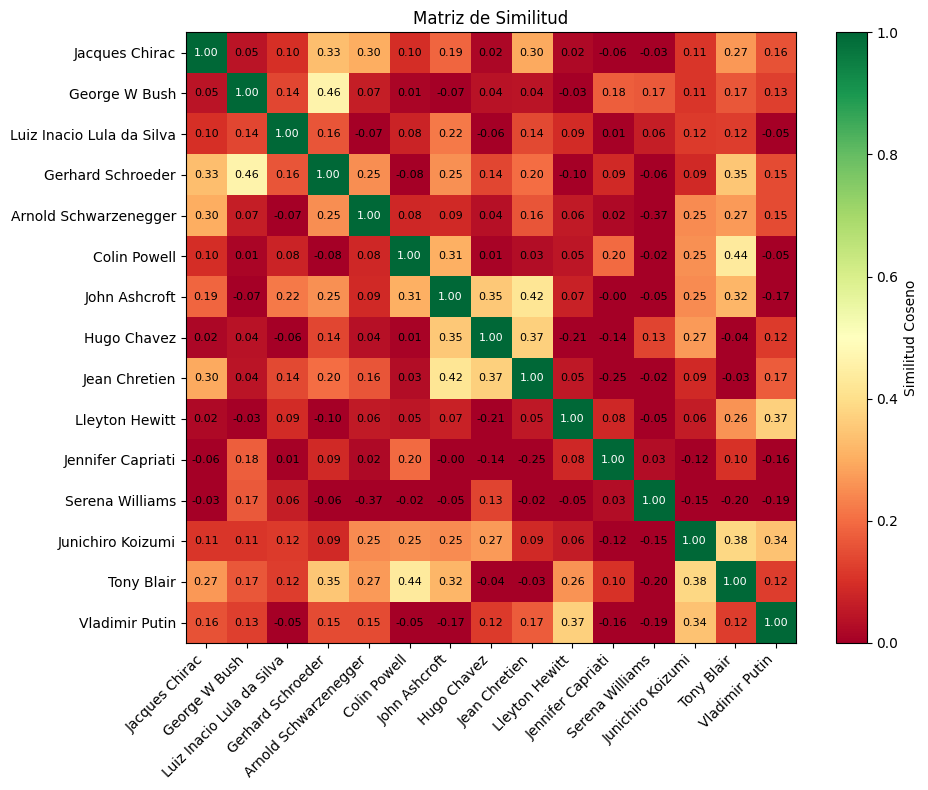

In [48]:
all_vectors = []
all_names = []

for persona, lista_de_embs in embeddings_db.items():
    for emb in lista_de_embs:
        all_vectors.append(emb.flatten())
        all_names.append(persona)


emb_array = np.array(all_vectors)
emb_labels = np.array(all_names)

print(f"Matriz creada con éxito. Forma: {emb_array.shape}")

plt.close('all')

nombres_unicos = list(embeddings_db.keys())
n_muestras = 15
muestra_personas = random.sample(nombres_unicos, min(n_muestras, len(nombres_unicos)))

emb_sample = []
labels_sample = []

for persona in muestra_personas:
    emb_sample.append(embeddings_db[persona][0])
    labels_sample.append(persona.replace('_', ' '))

emb_sample = np.array(emb_sample)

norms = np.linalg.norm(emb_sample, axis=1, keepdims=True)
emb_sample_norm = emb_sample / (norms + 1e-8)
sim_matrix = emb_sample_norm @ emb_sample_norm.T

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="Similitud Coseno")

ticks = range(len(labels_sample))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(labels_sample, rotation=45, ha="right")
ax.set_yticklabels(labels_sample)

for i in range(len(labels_sample)):
    for j in range(len(labels_sample)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", 
                ha="center", va="center", 
                color="black" if sim_matrix[i, j] < 0.7 else "white", 
                fontsize=8)

ax.set_title("Matriz de Similitud")
plt.tight_layout()
plt.show()

**EVALUACIÓN**

In [ ]:
lfw = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True)
X_raw = lfw.images
y_lfw = lfw.target
names = lfw.target_names

print(f"LFW: {X_raw.shape[0]} imágenes, {len(names)} personas")
print(f"Personas: {list(names)}")


def preprocess_lfw(imgs):
    out = []
    for img in imgs:
        arr = (img * 255).astype(np.uint8)
        arr = cv2.resize(arr, (160, 160))
        arr = (arr.astype(np.float32) - 127.5) / 128.0
        out.append(arr.transpose(2, 0, 1))
    return torch.tensor(np.array(out), dtype=torch.float32)


lfw_embs = []
BATCH = 64
modelo.eval()

for i in range(0, len(X_raw), BATCH):
    batch = preprocess_lfw(X_raw[i : i + BATCH])
    with torch.no_grad():
        embeddings = modelo(batch).numpy()
        lfw_embs.append(embeddings)

lfw_embs = np.vstack(lfw_embs)
print(f"Embeddings: {lfw_embs.shape}")


X_gal, X_qry, y_gal, y_qry = train_test_split(
    lfw_embs, y_lfw, test_size=0.3, stratify=y_lfw, random_state=42)


sims = X_qry @ X_gal.T

preds = y_gal[sims.argmax(axis=1)]

accuracy = (preds == y_qry).mean()
print(f"Accuracy LFW: {accuracy:.2%}")

LFW: 1288 imágenes, 7 personas
Personas: ['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush', 'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair']
Embeddings: (1288, 512)
Accuracy LFW: 99.74%


**FINE-TUNING**

In [50]:
data_dir = Path("src/data/processed")

image_paths = []
labels = []

for person_dir in data_dir.iterdir():
    if person_dir.is_dir():
        for img_path in person_dir.glob("*.[jp][pn]g"): 
            image_paths.append(str(img_path))
            labels.append(person_dir.name)

print(f"Se encontraron {len(image_paths)} imágenes de {len(set(labels))} personas.")

Se encontraron 3359 imágenes de 20 personas.


In [ ]:
mtcnn = MTCNN(image_size=160, margin=0)
own_tensors, own_labels_raw = [], []
for p, lbl in zip(image_paths, labels):
    face = mtcnn(Image.open(p).convert("RGB"))
    if face is None:
        continue

    own_tensors.append(face[0] if face.ndim == 4 else face)
    own_labels_raw.append(lbl)

n_per_lfw = max(len(own_tensors) // len(set(own_labels_raw)), 3)
lfw_tensors, lfw_labels_raw = [], []

for cls_idx, cls_name in enumerate(names):

    idxs = np.where(y_lfw == cls_idx)[0][:n_per_lfw]

    for t in preprocess_lfw(X_raw[idxs]):
        lfw_tensors.append(t)
        lfw_labels_raw.append(cls_name)

all_tensors = own_tensors + lfw_tensors
all_labels_raw = own_labels_raw + lfw_labels_raw

le_ft = LabelEncoder()
y_all = torch.tensor(le_ft.fit_transform(all_labels_raw), dtype=torch.long)
X_all = torch.stack(all_tensors)

loader = DataLoader(TensorDataset(X_all, y_all), batch_size=8, shuffle=True)
print(f"Fine-tuning: {len(all_tensors)} imágenes | {len(le_ft.classes_)} clases")

for p in modelo.parameters():
    p.requires_grad = False

for p in modelo.last_linear.parameters():
    p.requires_grad = True
for p in modelo.last_bn.parameters():
    p.requires_grad = True

head = nn.Linear(512, len(le_ft.classes_))

"""optimizer = torch.optim.Adam(list(modelo.last_linear.parameters()) + 
    list(modelo.last_bn.parameters()) + 
    list(head.parameters()), 
    lr=1e-4)""""

optimizer = torch.optim.Adam([ {'params': modelo.last_linear.parameters(), 'lr': 1e-5},
    {'params': modelo.last_bn.parameters(), 'lr': 1e-5},    
    {'params': head.parameters(), 'lr': 1e-3}])

criterion = nn.CrossEntropyLoss()

modelo.train()
head.train()
for epoch in range(10):
    total_loss = 0
    for batch_X, batch_y in loader:
        optimizer.zero_grad()

        embeddings = modelo(batch_X)
        outputs = head(embeddings)
        
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Época {epoch+1} - Loss: {total_loss/len(loader):.4f}")

Fine-tuning: 3840 imágenes | 27 clases
Época 1 - Loss: 2.9233
Época 2 - Loss: 2.4612
Época 3 - Loss: 2.1107
Época 4 - Loss: 1.8445
Época 5 - Loss: 1.6345
Época 6 - Loss: 1.4752
Época 7 - Loss: 1.3215
Época 8 - Loss: 1.2064
Época 9 - Loss: 1.1008
Época 10 - Loss: 1.0177


**GUARDADO**

In [52]:
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "facenet_finetuned.pth")

torch.save(modelo.state_dict(), model_path)

print(f"guardado en: {model_path}")

guardado en: models\facenet_finetuned.pth


**PCA y TSNE**

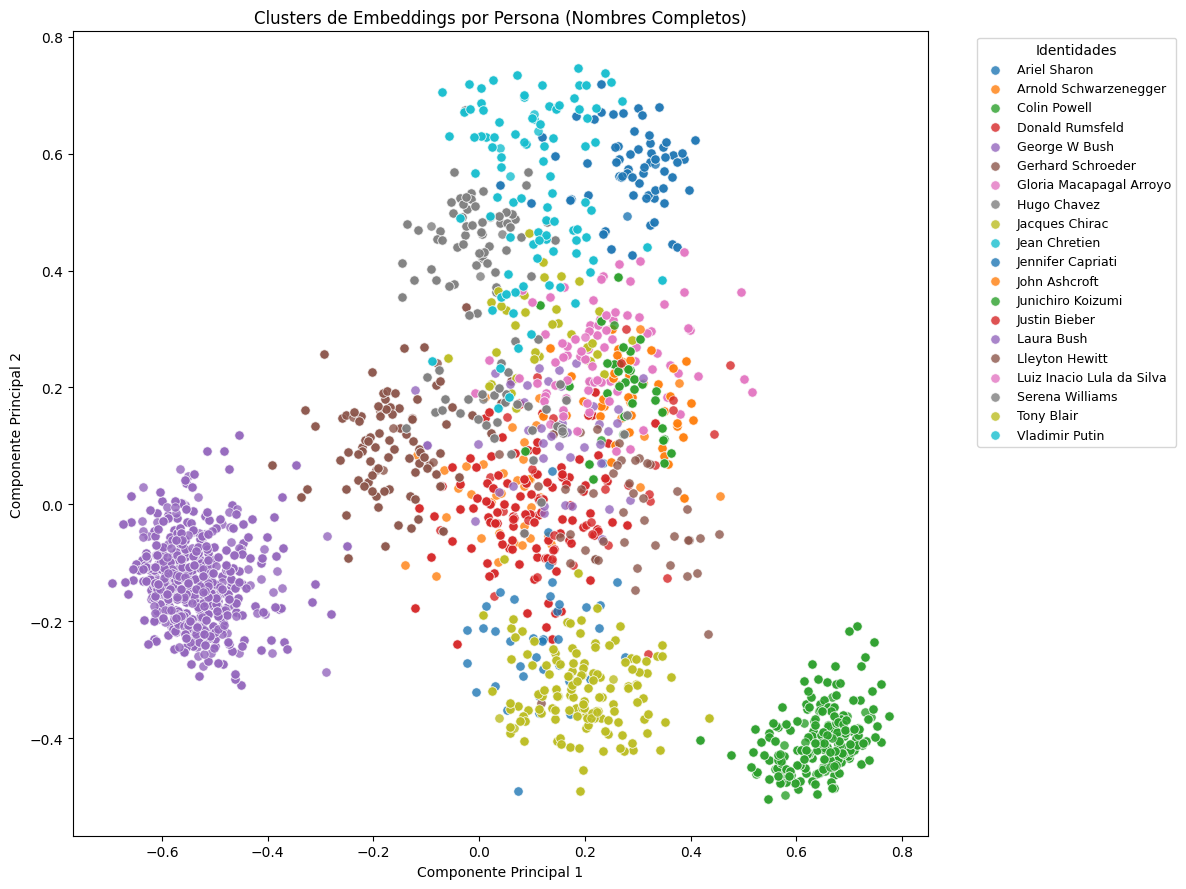

In [53]:
all_vectors = []
all_labels = []

for persona, lista_embs in embeddings_db.items():
    for emb in lista_embs:
        all_vectors.append(emb.flatten())
        all_labels.append(persona.replace('_', ' '))

emb_array = np.array(all_vectors)
emb_labels = np.array(all_labels)

le = LabelEncoder()
le.fit(emb_labels)

fig, ax = plt.subplots(figsize=(12, 9))

for persona in le.classes_:
    mask = emb_labels == persona
    
    ax.scatter(emb_pca[mask, 0], 
        emb_pca[mask, 1], 
        label=persona,
        s=45, 
        alpha=0.8,
        edgecolors='white',
        linewidths=0.5)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Identidades", ncol=1, fontsize=9)
ax.set_title("Clusters de Embeddings por Persona (Nombres Completos)")
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")

plt.tight_layout()
plt.show()

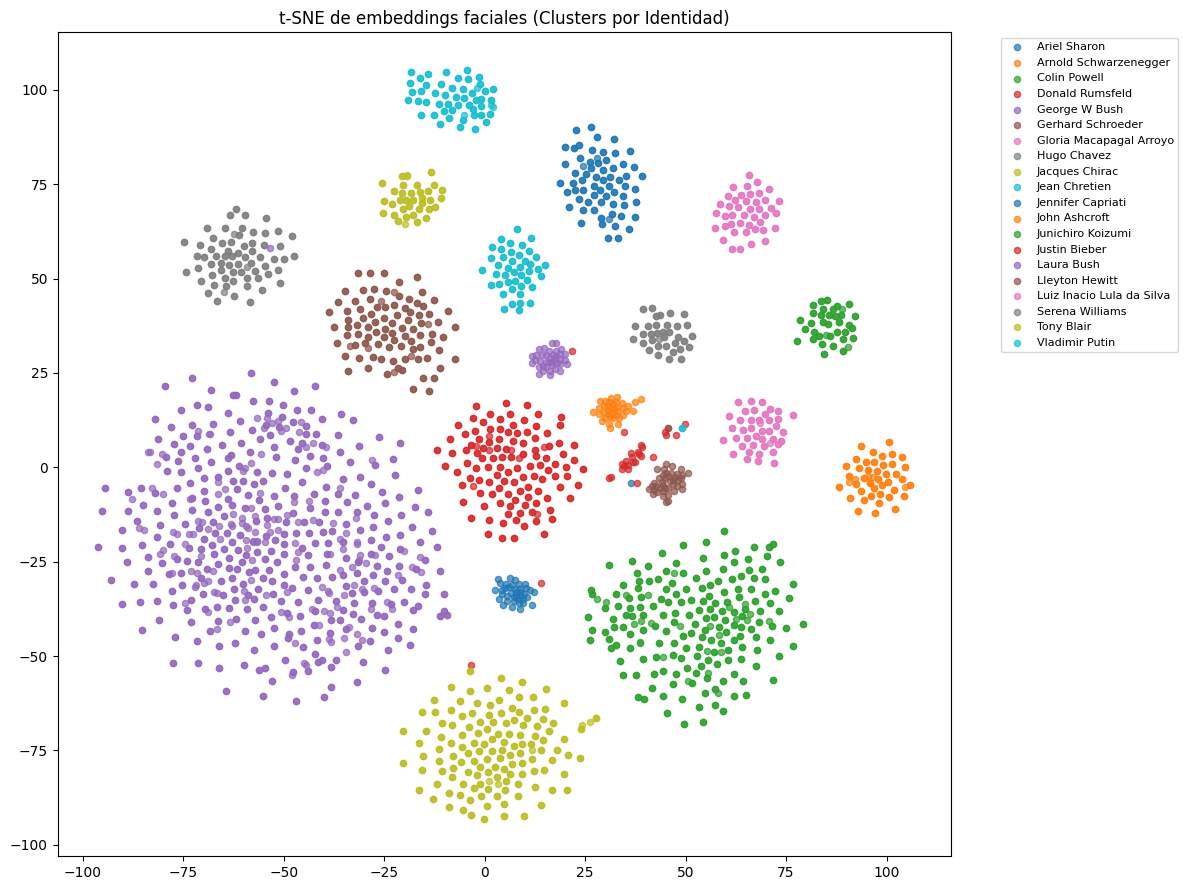

In [54]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(emb_array)

fig, ax = plt.subplots(figsize=(12, 9))

for persona in le.classes_:
    mask = emb_labels == persona 

    if not np.any(mask):
        continue 

    ax.scatter(emb_tsne[mask, 0], 
        emb_tsne[mask, 1], 
        label=persona, 
        alpha=0.7, 
        s=20)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
ax.set_title('t-SNE de embeddings faciales (Clusters por Identidad)')
plt.tight_layout()
plt.show()